# Abnormal Volume and Future Regime Transitions (Stage 12)

## Research role
Volume is tested only after regimes and transition targets were finalized. It was excluded from HMM formation, preventing the outcome from defining the regimes it is now compared against. This stage evaluates training-period association and descriptive event timing—not causality or out-of-sample predictive improvement.

In [1]:
from pathlib import Path
import json,pandas as pd
from IPython.display import Image,display
ROOT=Path.cwd(); ROOT=ROOT.parent if ROOT.name=='notebooks' else ROOT
T=ROOT/'outputs'/'tables'; M=ROOT/'outputs'/'models'; F=ROOT/'outputs'/'figures'
group=pd.read_csv(T/'volume_transition_group_summary.csv'); anova=pd.read_csv(T/'volume_two_way_anova.csv')
hac=pd.read_csv(T/'volume_hac_regression.csv'); robust=pd.read_csv(T/'volume_robust_tests.csv')
boot=pd.read_csv(T/'volume_block_bootstrap.csv'); windows=pd.read_csv(T/'transition_event_windows.csv')
events=pd.read_csv(T/'transition_event_summary.csv'); meta=json.loads((M/'volume_anova_metadata.json').read_text())
meta

{'training_cutoff': '2017-12-31',
 'primary_outcome': 'Log_Abnormal_Volume',
 'primary_target': 'Any_Transition_Within_5D',
 'garch_tertile_thresholds': {'low_medium': 0.007142284694485,
  'medium_high': 0.010788124806444099},
 'anova_type': 'Type III',
 'contrasts': 'Treatment contrasts; Transition=0 and Volatility=Low references',
 'hac_max_lag': 5,
 'block_length': 20,
 'bootstrap_seed': 12012,
 'bootstrap_replications': 2000,
 'multiple_testing_adjustment': 'Holm',
 'confidence_level': 0.95,
 'primary_sample_size': 4272,
 'transition_count': 746,
 'limitations': ['Association, not causation or out-of-sample prediction',
  'Overlapping targets induce dependence',
  'HC3 is not serial-correlation robust',
  'Confidence filtering can remove genuine boundary events']}

## Primary outcome and model
`Log_Abnormal_Volume` is primary because raw abnormal volume is positively skewed; raw values are a robustness outcome. The training-only model is
$$LogAV_t=\beta_0+\beta_1Transition_t+\beta_2VolatilityCategory_t+\beta_3(Transition_t\times VolatilityCategory_t)+\epsilon_t.$$
Treatment references are no transition (`0`) and Low volatility. The transition coefficient is the difference at Low volatility; volatility coefficients compare no-transition observations with Low; interactions test whether transition-associated differences vary by category. Insignificant interaction evidence does not prove equality.

## Training-only volatility tertiles and structural missingness
Low/Medium/High thresholds were estimated once from the primary training sample. Test observations never select thresholds or specifications. Structurally inapplicable secondary outcomes remain missing and are excluded rather than recoded as zero.

In [2]:
group[(group.Target=='Any_Transition_Within_5D')&(group.Outcome=='Log_Abnormal_Volume')].round(5)

,Target,Sample_Restriction,Outcome,Transition_Group,Volatility_Category,N,Mean,Median,Std,SE,CI_Lower,CI_Upper
0,Any_Transition_Within_5D,Primary training,Log_Abnormal_Volume,0,Low,1149,-0.03935,-0.04368,0.30736,0.00907,-0.05714,-0.02156
1,Any_Transition_Within_5D,Primary training,Log_Abnormal_Volume,0,Medium,1107,-0.01233,-0.02272,0.32273,0.00970,-0.03136,0.00670
2,Any_Transition_Within_5D,Primary training,Log_Abnormal_Volume,0,High,1270,-0.04829,-0.07063,0.34590,0.00971,-0.06733,-0.02925
3,Any_Transition_Within_5D,Primary training,Log_Abnormal_Volume,1,Low,275,0.01214,-0.00496,0.30696,0.01851,-0.02430,0.04858
4,Any_Transition_Within_5D,Primary training,Log_Abnormal_Volume,1,Medium,317,-0.14179,-0.15744,0.35547,0.01997,-0.18107,-0.10251
5,Any_Transition_Within_5D,Primary training,Log_Abnormal_Volume,1,High,154,0.05002,0.00755,0.39414,0.03176,-0.01273,0.11277
8,Any_Transition_Within_5D,All-high-confidence window,Log_Abnormal_Volume,0,All,3433,-0.03373,-0.04491,0.32521,0.00555,-0.04462,-0.02285
9,Any_Transition_Within_5D,All-high-confidence window,Log_Abnormal_Volume,1,All,442,-0.01625,-0.03856,0.36641,0.01743,-0.05051,0.01800


## Inference and effect sizes
Classical Type III ANOVA is shown for conventional decomposition, but iid assumptions are imperfect because daily finance data and overlapping five-observation targets are dependent. HC3 addresses heteroskedasticity, not serial correlation. HAC uses a prespecified lag of five. A chronological moving-block bootstrap uses length-20 blocks, seed 12012, and 2,000 requested replications. Practical magnitude is interpreted separately using mean/median differences, Hedges' g, rank effects, eta-squared, and partial eta-squared.

In [3]:
display(anova.round(6)); display(hac.round(6)); display(robust.head(12).round(6)); boot.round(6)

,Inference_Method,Term,Sum_Squares,DF,Statistic,P_Value,Eta_Squared,Partial_Eta_Squared
0,Classical Type III ANOVA,Intercept,1.778828,1.0,16.319535,0.000054,0.003776,0.003811
1,Classical Type III ANOVA,"C(Transition, Treatment(reference=0))",0.588300,1.0,5.397249,0.020215,0.001249,0.001264
2,Classical Type III ANOVA,"C(Volatility_Category, Treatment(reference='Lo...",0.812032,2.0,3.724922,0.024193,0.001724,0.001743
3,Classical Type III ANOVA,"C(Transition, Treatment(reference=0)):C(Volati...",5.965697,2.0,27.365607,0.000000,0.012662,0.012667
4,Classical Type III ANOVA,Residual,464.993602,4266.0,NaN,NaN,NaN,NaN
5,HC3 robust Type III,Intercept,2.050659,1.0,18.813400,0.000015,0.004353,0.004391
6,HC3 robust Type III,"C(Transition, Treatment(reference=0))",0.678111,1.0,6.221210,0.012660,0.001439,0.001456
7,HC3 robust Type III,"C(Volatility_Category, Treatment(reference='Lo...",0.816900,2.0,3.747250,0.023660,0.001734,0.001754
8,HC3 robust Type III,"C(Transition, Treatment(reference=0)):C(Volati...",5.268105,2.0,24.165641,0.000000,0.011182,0.011202
9,HC3 robust Type III,Residual,464.993602,4266.0,NaN,NaN,NaN,NaN


,Result_Type,Term,Estimate,HAC_SE,CI_Lower,CI_Upper,Statistic,P_Value,Reference_Categories,HAC_Max_Lag
0,Coefficient,Intercept,-0.039347,0.012506,-0.063865,-0.014828,-3.146239,0.001665,Transition=0; Volatility=Low,5
1,Coefficient,"C(Transition, Treatment(reference=0))[T.1]",0.051491,0.024293,0.003864,0.099117,2.119600,0.034097,Transition=0; Volatility=Low,5
2,Coefficient,"C(Volatility_Category, Treatment(reference='Lo...",0.027018,0.017521,-0.007332,0.061367,1.542031,0.123140,Transition=0; Volatility=Low,5
3,Coefficient,"C(Volatility_Category, Treatment(reference='Lo...",-0.008943,0.020052,-0.048256,0.030370,-0.445987,0.655629,Transition=0; Volatility=Low,5
4,Coefficient,"C(Transition, Treatment(reference=0))[T.1]:C(V...",-0.180953,0.036655,-0.252816,-0.109090,-4.936638,0.000001,Transition=0; Volatility=Low,5
5,Coefficient,"C(Transition, Treatment(reference=0))[T.1]:C(V...",0.046820,0.051960,-0.055050,0.148689,0.901067,0.367604,Transition=0; Volatility=Low,5
6,Joint_Wald_Test,Joint volatility-category terms,NaN,NaN,NaN,NaN,1.955325,0.141645,Transition=0; Volatility=Low,5
7,Joint_Wald_Test,Joint transition-by-volatility interactions,NaN,NaN,NaN,NaN,16.132541,0.000000,Transition=0; Volatility=Low,5


,Analysis,Target,Outcome,Sample_Restriction,Test,Statistic,P_Value,Adjusted_P_Value,Mean_Difference,Median_Difference,Hedges_g,Rank_Effect,A,B,mean_A,mean_B,diff,se,df
0,Primary two-group,Any_Transition_Within_5D,Log_Abnormal_Volume,Training,Welch unequal-variance t-test,-8.019260e-01,0.422782,0.422782,-0.011364,-0.013098,-0.034207,-0.031556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Primary two-group,Any_Transition_Within_5D,Log_Abnormal_Volume,Training,Mann-Whitney U,1.273695e+06,0.175071,0.175071,-0.011364,-0.013098,-0.034207,-0.031556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Primary two-group,Any_Transition_Within_5D,Abnormal_Volume,Raw-volume robustness,Welch unequal-variance t-test,8.409500e-02,0.932998,0.932998,0.001372,-0.012443,0.003729,-0.031556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Primary two-group,Any_Transition_Within_5D,Abnormal_Volume,Raw-volume robustness,Mann-Whitney U,1.273695e+06,0.175071,0.175071,0.001372,-0.012443,0.003729,-0.031556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Primary two-group,Any_Transition_Within_5D,Log_Abnormal_Volume,All-high-confidence window,Welch unequal-variance t-test,9.556740e-01,0.339669,0.339669,0.017480,0.006348,0.052934,0.015361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Primary two-group,Any_Transition_Within_5D,Log_Abnormal_Volume,All-high-confidence window,Mann-Whitney U,7.703470e+05,0.598618,0.598618,0.017480,0.006348,0.052934,0.015361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Primary two-group,Stress_Entry_Within_5D,Log_Abnormal_Volume,Secondary training,Welch unequal-variance t-test,6.483632e+00,0.000000,0.000000,0.320409,0.284732,0.989575,0.457340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Primary two-group,Stress_Entry_Within_5D,Log_Abnormal_Volume,Secondary training,Mann-Whitney U,1.306760e+05,0.000000,0.000000,0.320409,0.284732,0.989575,0.457340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Primary two-group,Stress_Exit_Within_5D,Log_Abnormal_Volume,Secondary training,Welch unequal-variance t-test,-1.758486e+00,0.082730,0.082730,-0.068242,-0.058065,-0.199731,-0.124638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Primary two-group,Stress_Exit_Within_5D,Log_Abnormal_Volume,Secondary training,Mann-Whitney U,4.107200e+04,0.082364,0.082364,-0.068242,-0.058065,-0.199731,-0.124638,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Statistic,Sample_Restriction,Volatility_Category_or_Contrast,Point_Estimate,CI_Lower,CI_Upper,Requested_Replications,Valid_Replications,Failed_Replications,Block_Length,Seed
0,Transition minus no-transition mean difference,Training,Overall,-0.011364,-0.052182,0.028535,2000,2000,0,20,12012
1,Transition minus no-transition mean difference,Training,Low,0.051491,0.003967,0.103074,2000,2000,0,20,12012
2,Transition minus no-transition mean difference,Training,Medium,-0.129462,-0.185033,-0.069042,2000,2000,0,20,12012
3,Transition minus no-transition mean difference,Training,High,0.098310,0.005520,0.195563,2000,2000,0,20,12012
4,Difference-in-differences,Training,Low minus Medium interaction,0.180953,0.104271,0.254592,2000,2000,0,20,12012
5,Difference-in-differences,Training,Low minus High interaction,-0.046820,-0.158408,0.057429,2000,2000,0,20,12012
6,Difference-in-differences,Training,Medium minus High interaction,-0.227772,-0.329031,-0.125251,2000,2000,0,20,12012


Games–Howell comparisons, when present, are exploratory six-cell comparisons justified by omnibus evidence and use Holm adjustment. Confidence-window restriction is also robustness-only: assignment uncertainty is endogenous to regime boundaries and may remove genuine transitions.

## Secondary transition types
Stress entry, stress exit, acute entry, worsening, and improving use their applicable training denominators. Acute entries are rare and are not treated as strong confirmatory evidence. The prespecified primary association remains any transition within five observations.

In [4]:
group[(group.Sample_Restriction=='Secondary training')&(group.Outcome=='Log_Abnormal_Volume')].round(5)

,Target,Sample_Restriction,Outcome,Transition_Group,Volatility_Category,N,Mean,Median,Std,SE,CI_Lower,CI_Upper
10,Stress_Entry_Within_5D,Secondary training,Log_Abnormal_Volume,0,All,2759,-0.04400,-0.04750,0.32185,0.00613,-0.05602,-0.03199
11,Stress_Entry_Within_5D,Secondary training,Log_Abnormal_Volume,1,All,65,0.27641,0.23723,0.39535,0.04904,0.17844,0.37437
12,Stress_Exit_Within_5D,Secondary training,Log_Abnormal_Volume,0,All,1380,-0.03178,-0.05393,0.34291,0.00923,-0.04988,-0.01367
13,Stress_Exit_Within_5D,Secondary training,Log_Abnormal_Volume,1,All,68,-0.10002,-0.11199,0.31083,0.03769,-0.17525,-0.02478
14,Acute_Entry_Within_5D,Secondary training,Log_Abnormal_Volume,0,All,3871,-0.03953,-0.04723,0.32562,0.00523,-0.04979,-0.02927
15,Acute_Entry_Within_5D,Secondary training,Log_Abnormal_Volume,1,All,40,0.33451,0.33269,0.34027,0.05380,0.22569,0.44334
16,Stress_Worsening_Within_5D,Secondary training,Log_Abnormal_Volume,0,All,3562,-0.04668,-0.05546,0.32414,0.00543,-0.05733,-0.03603
17,Stress_Worsening_Within_5D,Secondary training,Log_Abnormal_Volume,1,All,349,0.07632,0.04743,0.34508,0.01847,0.03999,0.11265
18,Stress_Improving_Within_5D,Secondary training,Log_Abnormal_Volume,0,All,2388,-0.00154,-0.01937,0.34562,0.00707,-0.01541,0.01233
19,Stress_Improving_Within_5D,Secondary training,Log_Abnormal_Volume,1,All,397,-0.15249,-0.15671,0.33184,0.01665,-0.18524,-0.11975


## Event time
A unique event occurs at the first destination-state date $\tau$ where $S_\tau\ne S_{\tau-1}$, with event time $k=-10,\ldots,+10$. Each transition date appears once. Windows flag other transitions, and sensitivity summaries exclude events contaminated in the pre-event window. Post-event observations are descriptive and must never become predictors for an already-realized event. Window observations are not independent events.

In [5]:
pd.DataFrame({'unique_events':[windows.Event_ID.nunique()],'training_events':[windows.loc[windows.Event_Sample=='Train','Event_ID'].nunique()],
'overlapping_events':[windows.loc[windows.Another_Transition_In_Window,'Event_ID'].nunique()],
'prewindow_contaminated':[windows.loc[windows.Another_Transition_In_Pre_Window,'Event_ID'].nunique()]})

,unique_events,training_events,overlapping_events,prewindow_contaminated
0,262,172,157,98


## Figures and interpretation limits
The figures summarize distribution, interaction-scale means, block-bootstrap effects, event time, secondary types, and confidence robustness. Results are associations in the training period. Stage 13 is required before any claim that volume improves unseen-period transition prediction.

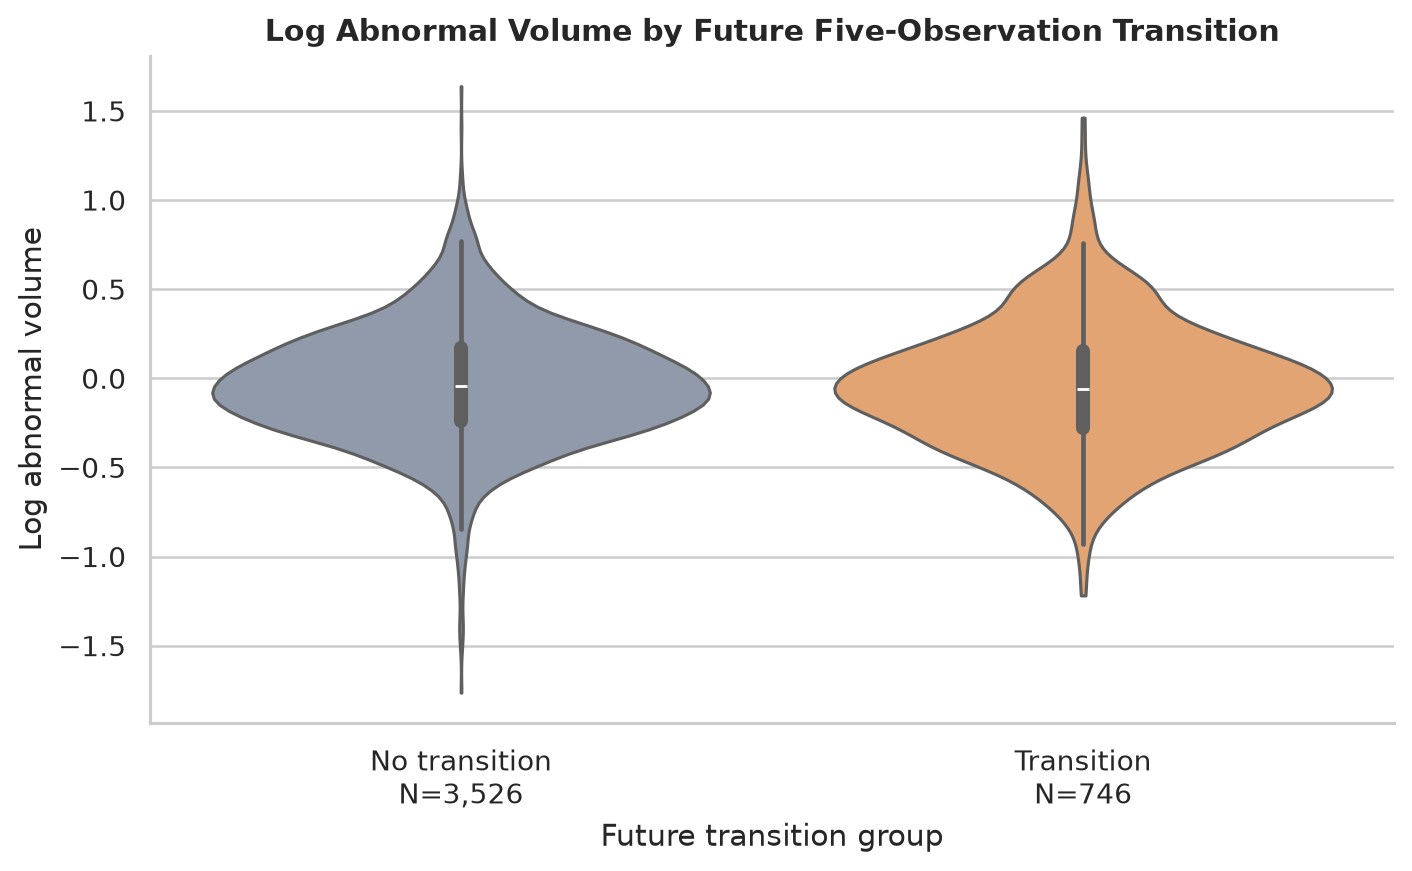

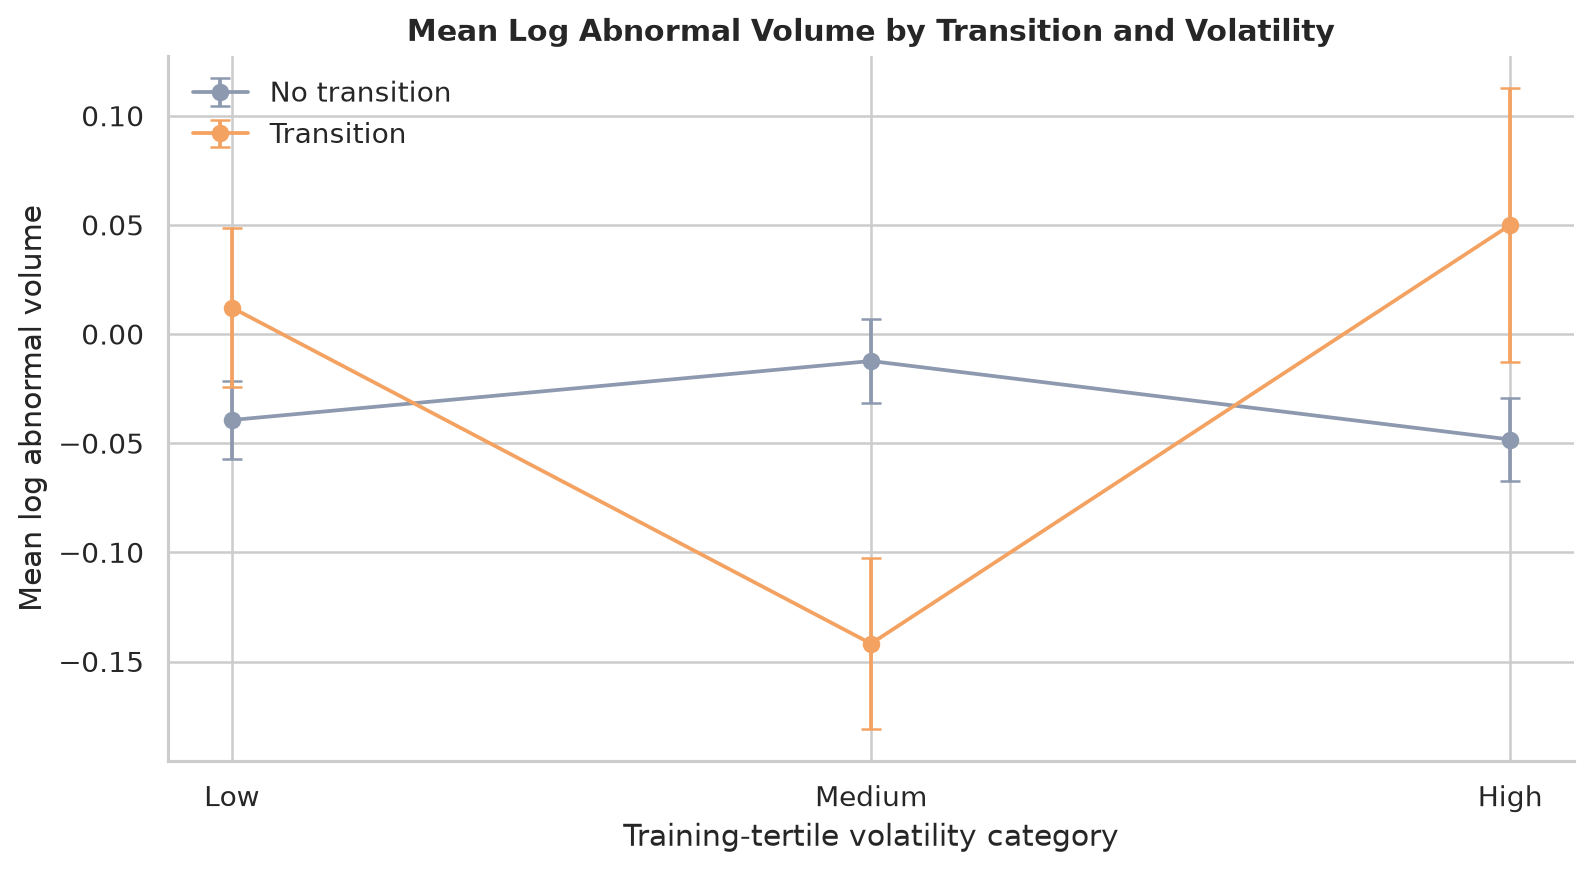

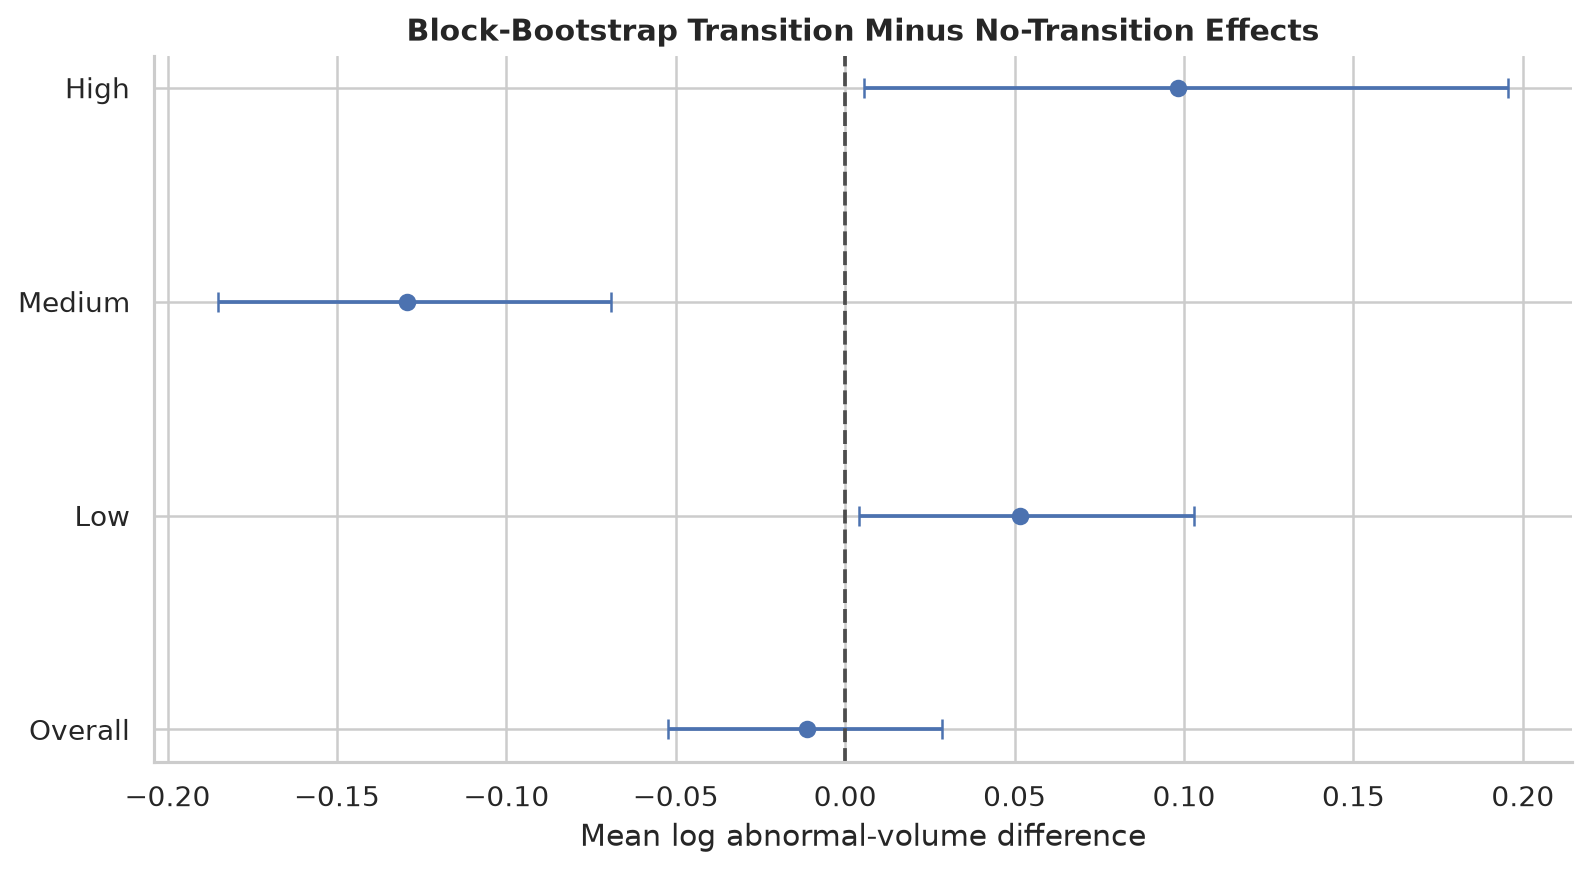

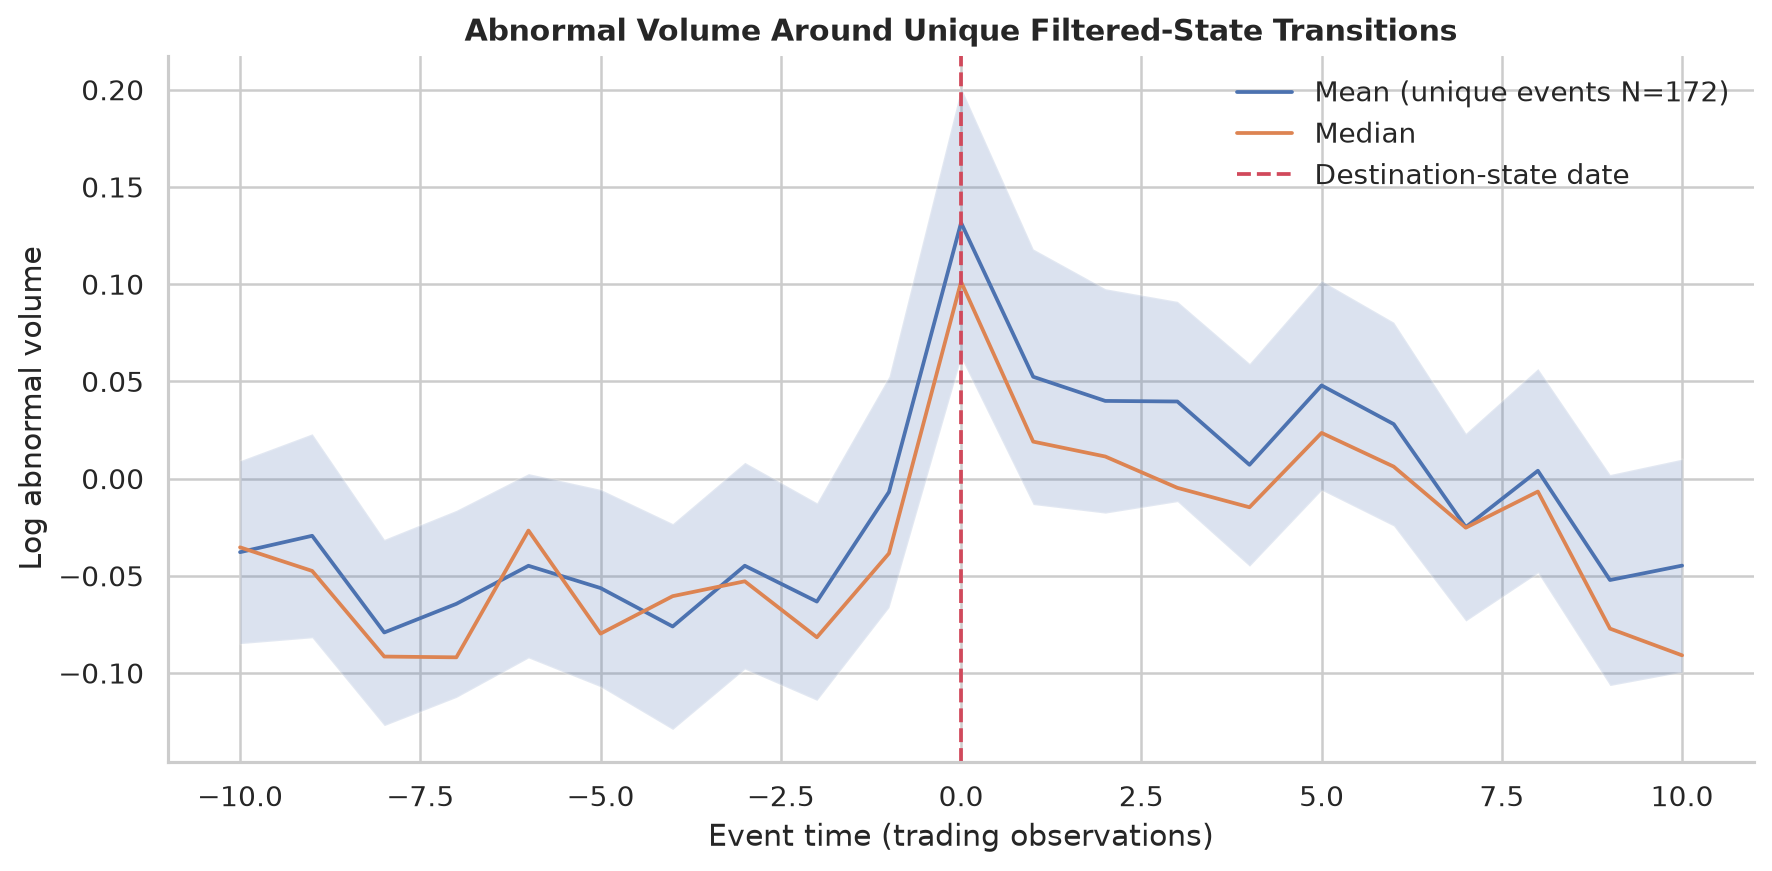

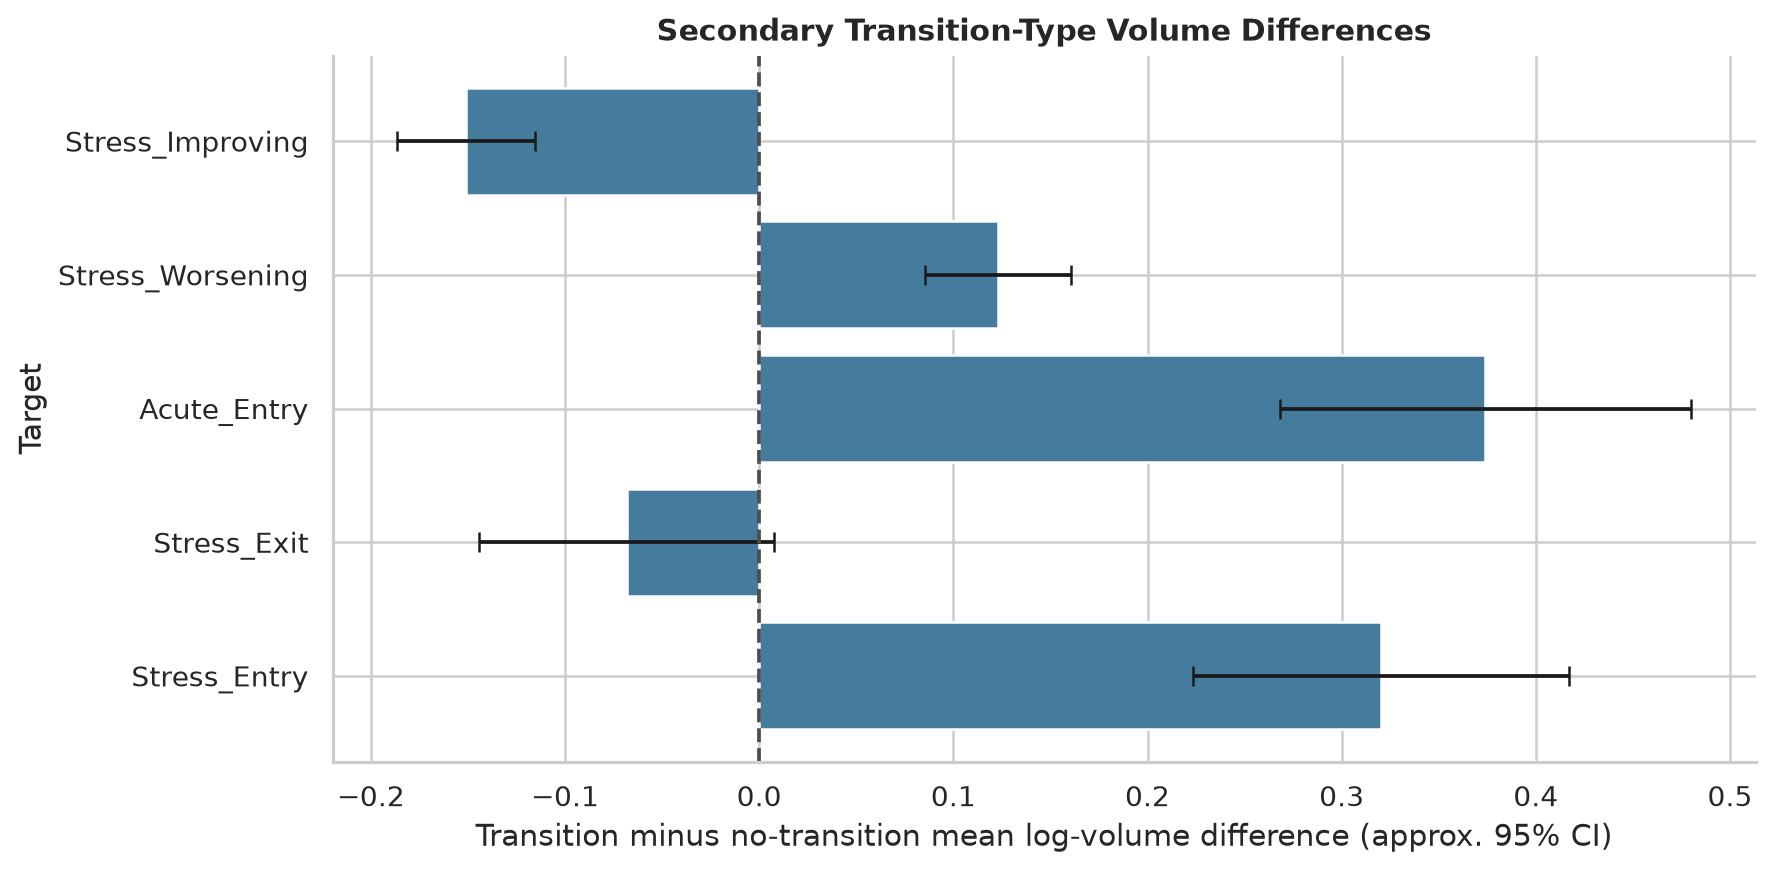

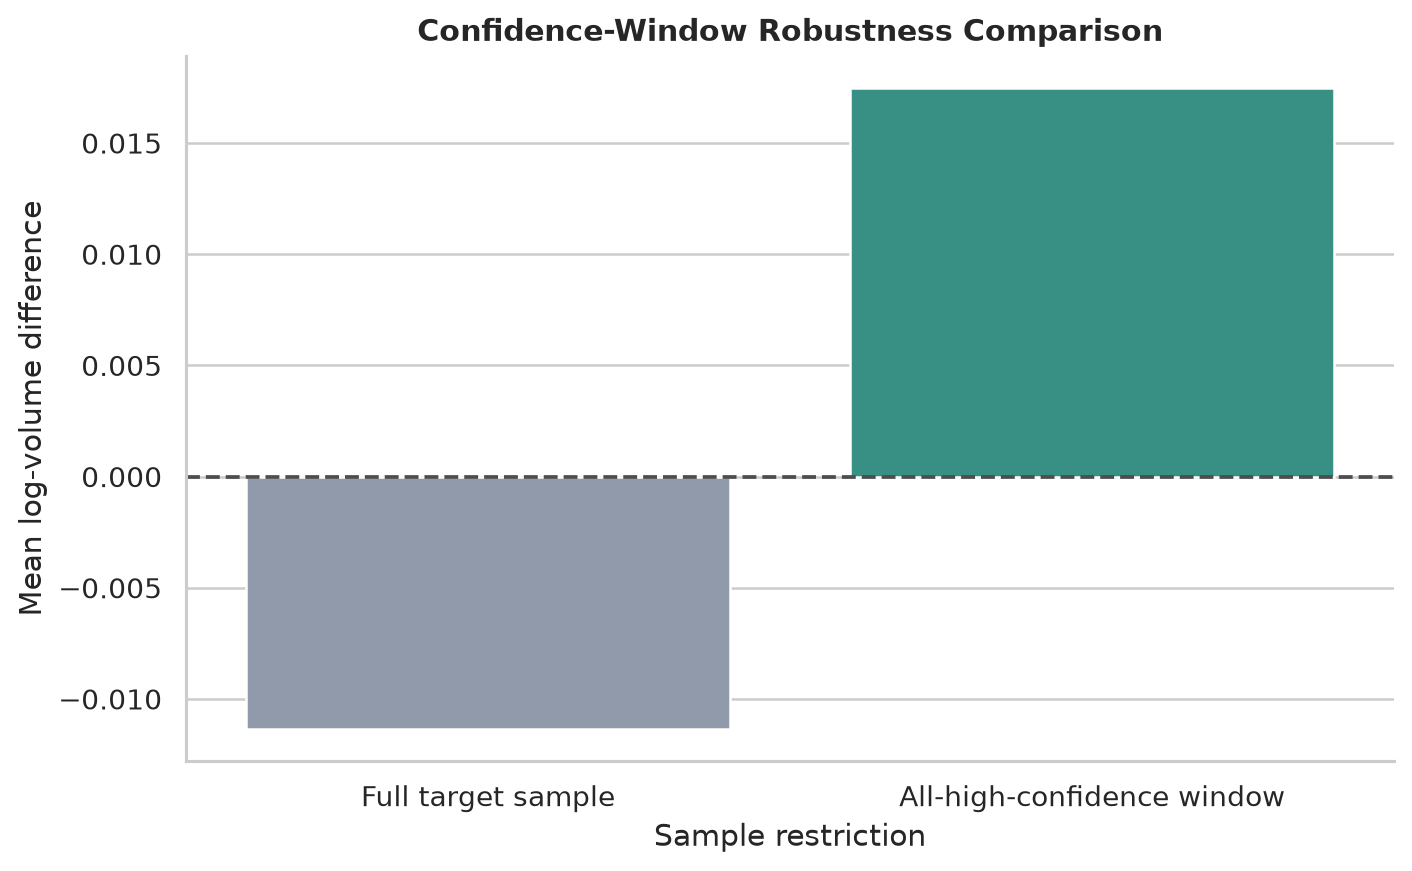

In [6]:
names=['volume_by_future_transition.png','volume_transition_by_volatility.png','volume_effect_sizes.png','transition_event_volume_path.png','transition_type_volume_comparison.png','volume_confidence_robustness.png']
for name in names:
 p=F/name; assert p.exists() and p.stat().st_size>0; display(Image(filename=str(p),width=900))